# 北捷 OD 資料前處理

先保留完整的「日期 × 小時 × 起站 × 迄站」長表，再產生回歸與流向分析所需的小表。

這份 notebook 是逐步操作與檢查介面，實際清理規則沿用 `src/data_preprocessing.py` 與 `src/aggregate_flows.py`，避免維護兩套不同算法。

**預設：2026 年 7、8 月；北門站；18:00 ≤ 時間 < 次日 00:00。**

- 不修改原始 CSV、不寫入 MySQL，也不覆蓋原本全量分析表。
- MySQL 僅讀取既有活動／聲量資料，透過本機 login path 連線；不在 notebook 放密碼。
- 原始 notebook 已保留於 `.local/notebook_backups/`。

第一次使用：在專案根目錄執行 `uv sync --group notebook`，並選擇專案 `.venv/Scripts/python.exe` 作為 notebook Python 核心。

## 1. 設定範圍與盤點檔案

目前先用兩個月確認流程。`MONTHS = None` 可切換為所有已下載的 `YYYYMM.csv`；這不代表資料包含每個年份的全部月份。先不要只留下煙火日，因為一般日資料後續可提供比較基準。

In [1]:
from pathlib import Path
import sys
import re
import json
from datetime import datetime, timezone

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 從專案根目錄或 notebooks 目錄執行都能找到資料，不寫死使用者路徑。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/data_preprocessing.py').is_file()
             and (p / 'data/original_data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('請從本專案根目錄或 notebooks 目錄開啟此 notebook。')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from data_preprocessing import clean_month, literal
from aggregate_flows import build_analysis
from load_data import event_snapshot

MONTHS = ['202607', '202608']  # 改成 None：處理現有全部月份。
STATION = '北門'
START_HOUR, END_HOUR = 18, 24  # 結束時間不包含在內；26 代表延伸至次日 02:00。
FOCUS_EVENT = None             # None：採此範圍內第一個事件日期；也可填 '2026-07-25'。
LOGIN_PATH = 'codex-local'
FORCE_CLEAN = False

assert 0 <= START_HOUR < END_HOUR <= 48
available = sorted(p for p in (ROOT / 'data/original_data').glob('*.csv')
                   if re.fullmatch(r'20\d{4}', p.stem))
raw_paths = [p for p in available if MONTHS is None or p.stem in MONTHS]
if not raw_paths or (MONTHS is not None and set(MONTHS) - {p.stem for p in raw_paths}):
    raise FileNotFoundError('指定月份缺檔，請檢查 MONTHS 與 data/original_data。')
months = [p.stem for p in raw_paths]
run_name = ('all_months' if MONTHS is None else '_'.join(months)) + f'_h{START_HOUR}_{END_HOUR}'
CLEAN = ROOT / 'data/interim/clean_od'
OUT = ROOT / 'data/processed/propressing' / run_name
QA = ROOT / 'results/preprocessing/notebook' / run_name
TEMP = ROOT / '.local/duckdb_tmp/propressing'
for directory in (CLEAN, OUT, QA, TEMP):
    directory.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("SET memory_limit='2GB'")
con.execute('SET threads=4')
con.execute('SET temp_directory=?', [str(TEMP)])
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 24)
display(pd.DataFrame([{'月份': p.stem, '檔名': p.name,
                       '大小_MB': round(p.stat().st_size / 1024**2, 1)} for p in raw_paths]))
print('輸出資料夾：', OUT)

ModuleNotFoundError: No module named 'duckdb'

In [ ]:
# 只預覽少量資料；不要將數百萬列原始 CSV 全部讀入 pandas。
display(con.execute('SELECT * FROM read_csv(?, all_varchar=true, header=true) LIMIT 8',
                    [str(raw_paths[0])]).df())

,日期,時段,進站,出站,人次
0,2026-07-01,00,松山機場,松山機場,0
1,2026-07-01,00,松山機場,中山國中,0
2,2026-07-01,00,松山機場,南京復興,1
3,2026-07-01,00,松山機場,忠孝復興,0
4,2026-07-01,00,松山機場,大安,0
5,2026-07-01,00,松山機場,科技大樓,0
6,2026-07-01,00,松山機場,六張犁,0
7,2026-07-01,00,松山機場,麟光,0


## 2. 清理原始 OD：先定義規則，再做加總

| 項目 | 規則 |
|---|---|
| 欄位 | 日期、時段、進站、出站、人次必須齊全 |
| 型別 | 日期有效且屬於檔名月份；時段為 0–23 整數；人次為非負整數 |
| 站名 | 只去頭尾空白，不擅自合併異名或不同線別標籤 |
| 唯一鍵 | `service_date + source_hour + origin_station + destination_station` |
| 重複 | 同鍵且同人次只留一筆並記錄；同鍵但不同人次停止，不能相加 |
| 0 / 缺值 | 原始 0 保留；無效值停止；沒有資料不補 0 |
| 高值／同站進出 | 先保留。高值可能是活動訊號；同站進出另標記 |

清理結果保存成每月 Parquet。來源與輸出雜湊均一致時，重用已驗證快取。

`service_date` 是來源日期，尚未重建營運日；`hour_start` 按臺北本地時間解讀。來源時段究竟按進站或出站時間分箱尚待官方字典確認，因此迄站加總先稱「同來源時段迄站人次」，不能直接當成該小時出閘量。

In [ ]:
monthly_reports = []
for path in raw_paths:
    report = clean_month(con, path, CLEAN, ROOT / 'results/preprocessing/monthly',
                         force=FORCE_CLEAN)
    monthly_reports.append(report)
    print(path.name, '快取通過' if report.get('cached') else '已清理')

quality = pd.DataFrame(monthly_reports)
display(quality[['source_file', 'source_rows', 'clean_rows', 'invalid_rows',
                 'exact_duplicate_rows_removed', 'conflicting_keys', 'zero_rows', 'passengers']])
quality.to_csv(QA / 'monthly_quality.csv', index=False, encoding='utf-8-sig')
clean_paths = [CLEAN / f'{month}.parquet' for month in months]
con.read_parquet([str(p) for p in clean_paths]).create_view('od', replace=True)
display(con.execute('SELECT * FROM od LIMIT 8').df())

202607.csv 快取通過


202608.csv 快取通過


,source_file,source_rows,clean_rows,invalid_rows,exact_duplicate_rows_removed,conflicting_keys,zero_rows,passengers
0,202607.csv,8366652,8366652,0,0,0,3322037,63379613
1,202608.csv,8515080,8515080,0,0,0,3359345,64714014


,service_date,source_hour,origin_station,destination_station,passengers,source_row,source_month,hour_start
0,2026-07-01,0,BL板橋,BL板橋,0,7304,202607,2026-07-01
1,2026-07-01,0,BL板橋,G大坪林,0,7265,202607,2026-07-01
2,2026-07-01,0,BL板橋,O景安,0,7275,202607,2026-07-01
3,2026-07-01,0,BL板橋,O頭前庄,0,7329,202607,2026-07-01
4,2026-07-01,0,BL板橋,七張,1,7264,202607,2026-07-01
5,2026-07-01,0,BL板橋,三和國中,2,7341,202607,2026-07-01
6,2026-07-01,0,BL板橋,三民高中,1,7339,202607,2026-07-01
7,2026-07-01,0,BL板橋,三重,0,7331,202607,2026-07-01


## 3. 檢查完整性：空白時段與零人次不同

以下列出每個月每一小時有幾天出現在來源中，並核對已觀測起站與迄站集合的配對數。

即使配對齊全，也無法排除「整個站、整個日期或整個時段完全漏報」。沒有出現的時段先標為來源缺列；要判斷是否停駛，需再查營運資料，不自動補成 0。

In [ ]:
coverage = con.execute("""
    SELECT service_date, source_hour,
           count(DISTINCT origin_station) AS observed_origins,
           count(DISTINCT destination_station) AS observed_destinations,
           count(*) AS observed_pairs,
           count(*) = count(DISTINCT origin_station) * count(DISTINCT destination_station)
               AS pairs_complete_within_observed_sets
    FROM od GROUP BY service_date, source_hour
    ORDER BY service_date, source_hour
""").df()
coverage.to_csv(QA / 'observed_bin_coverage.csv', index=False, encoding='utf-8-sig')

calendar = pd.DataFrame([{'service_date': day, 'source_hour': hour}
                        for month in months
                        for day in pd.date_range(pd.to_datetime(month, format='%Y%m'),
                                                 pd.to_datetime(month, format='%Y%m') + pd.offsets.MonthEnd(0))
                        for hour in range(24)])
calendar = calendar.merge(coverage, on=['service_date', 'source_hour'], how='left', validate='one_to_one')
calendar['source_bin_present'] = calendar['observed_pairs'].notna()
calendar['source_month'] = calendar['service_date'].dt.strftime('%Y%m')
calendar.to_csv(QA / 'calendar_hour_coverage.csv', index=False, encoding='utf-8-sig')
display(calendar.groupby(['source_month', 'source_hour'])['source_bin_present'].sum()
        .unstack('source_hour', fill_value=0))
print('日曆時段未見於來源的列數：', int((~calendar['source_bin_present']).sum()))
print('已觀測集合內 OD 配對不完整的時段數：', int((~coverage['pairs_complete_within_observed_sets']).sum()))
display(con.execute("""SELECT source_month, count(DISTINCT origin_station) AS origin_labels,
                   count(DISTINCT destination_station) AS destination_labels,
                   sum(passengers) FILTER(WHERE origin_station=destination_station) AS same_station_passengers
                   FROM od GROUP BY source_month ORDER BY source_month""").df())

source_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
source_month,,,,,,,,,,,,,,,,,,,,,,,,
202607,31,31,0,0,0,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31
202608,31,31,0,0,0,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31


日曆時段未見於來源的列數： 186
已觀測集合內 OD 配對不完整的時段數： 0


,source_month,origin_labels,destination_labels,same_station_passengers
0,202607,119,108,696046.0
1,202608,120,109,715975.0


## 4. 從 MySQL 讀取活動，建立不同用途的分析表

取消與延期日期一併保留。活動日期以本機事件表為準，這裡不重新查證公告；原 notebook 手寫的 `2026-08-01` 不自動當成已確認活動日。

此步只讀取 MySQL，不重新匯入原始 OD、不修改 `original_data`。

| 表格 | 每列代表什麼 | 用途 |
|---|---|---|
| `od` | 日期 × 小時 × 起站 × 迄站 | 共用乾淨底表 |
| `station_hourly` | 日期 × 小時 × 車站 | 活動／一般日的背景流量 |
| `regression_station_hourly` | 活動 × 小時 × 車站 | 逐時變化 |
| `regression_event_station` | 活動 × 車站 × 分析視窗 | 聲量／活動特性的回歸 |
| `flow_edges_hourly` | 活動 × 小時 × 起站 × 迄站 | 有向加權圖 |

大表保留 Parquet；小表另外輸出 CSV。

In [ ]:
all_records = event_snapshot(LOGIN_PATH)
records = [r for r in all_records if r['event_date'][:7].replace('-', '') in months]
if not records:
    raise ValueError('所選月份沒有事件表中的日期；請調整 MONTHS。')
events_df = pd.DataFrame(records)
display(events_df[['event_date', 'event_name', 'event_status', 'announced_show_start_time',
                   'has_drone_show', 'not_held_reason']])
(QA / 'events_used.json').write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding='utf-8')

analysis_report = build_analysis(con, clean_paths, records, OUT,
                                 start_hour=START_HOUR, end_hour=END_HOUR)
print('分析表已輸出；MySQL 未寫入。')
display(pd.DataFrame(analysis_report['row_counts'].items(), columns=['表格', '列數']))

,event_date,event_name,event_status,announced_show_start_time,has_drone_show,not_held_reason
0,2026-07-25,2026大稻埕夏日節,held,20:00:00,1,None
1,2026-08-05,2026大稻埕夏日節,held,20:00:00,0,None
2,2026-08-15,2026大稻埕夏日節,held,20:00:00,1,None


分析表已輸出；MySQL 未寫入。


,表格,列數
0,station_labels,123
1,station_hourly,159495
2,regression_station_hourly,8832
3,regression_event_station,368
4,flow_edges_hourly,503238
5,flow_nodes_hourly,8832


## 5. 先看北門：逐時表與一場一列的回歸表

起站加總 `origin_count`：固定來源日期、小時及起站，對所有迄站加總人次。

`origin_count_window` 是完整分析視窗的總人次；例如 18–24 共六個小時。缺任何一小時就保留空值，不以不完整總量比較。原 notebook 使用 20、21、22、23，實際區間是 **20:00–23:59**，不是只到 23:00。

歷史基準採相同星期、相同時段的前 7／14／21／28 天，排除事件表中的活動日期。`baseline_n_days` 記錄可用天數；不足時需補前一月資料。此基準未控制其他活動、國定假日或天氣。

In [ ]:
station_hourly = con.execute('SELECT * FROM station_hourly WHERE station=? ORDER BY service_date,source_hour',
                             [STATION]).df()
station_event_hourly = con.execute('SELECT * FROM regression_station_hourly WHERE station=? ORDER BY event_date,hour_start',
                                   [STATION]).df()
station_event_totals = con.execute('SELECT * FROM regression_event_station WHERE station=? ORDER BY event_date',
                                  [STATION]).df()
display(station_event_totals[['event_date', 'station', 'observed_event_status', 'origin_count_window',
                              'observed_origin_hours', 'expected_hours', 'baseline_origin_window',
                              'baseline_min_days', 'interest_1d', 'interest_3d_avg', 'interest_7d_avg']])
print('聲量空值仍為缺值，不改成 0。')

,event_date,station,observed_event_status,origin_count_window,observed_origin_hours,expected_hours,baseline_origin_window,baseline_min_days,interest_1d,interest_3d_avg,interest_7d_avg
0,2026-07-25,北門,held,19330,6,6,4131.333333,3,NaN,NaN,NaN
1,2026-08-05,北門,held,14044,6,6,5944.250000,4,NaN,NaN,NaN
2,2026-08-15,北門,held,21230,6,6,5244.333333,3,NaN,NaN,NaN


聲量空值仍為缺值，不改成 0。


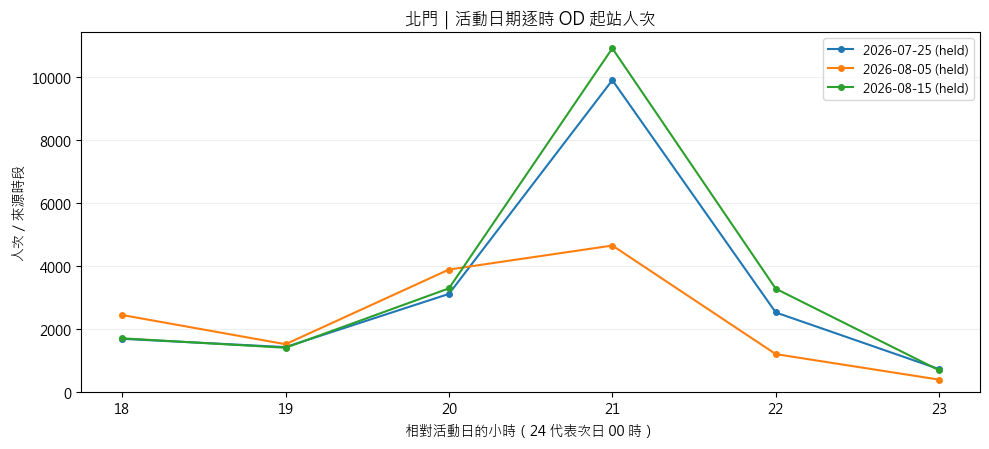

In [ ]:
# 圖上斷線代表缺資料，不代表流量為 0；只畫選定視窗。
fig, ax = plt.subplots(figsize=(10, 4.6))
plot_data = station_event_hourly.loc[station_event_hourly['in_target_window']].copy()
for event_date, group in plot_data.groupby('event_date'):
    group = group.sort_values('hour_offset')
    status = group['observed_event_status'].iloc[0]
    ax.plot(group['hour_offset'], group['origin_count'], marker='o', markersize=4,
            label=f'{event_date:%Y-%m-%d} ({status})')
ax.set(title=f'{STATION}｜活動日期逐時 OD 起站人次', xlabel='相對活動日的小時（24 代表次日 00 時）', ylabel='人次／來源時段')
ax.set_xticks(range(START_HOUR, END_HOUR, max(1, (END_HOUR-START_HOUR)//12)))
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=.2)
if not plot_data.empty:
    ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT / 'focus_station_event_hourly.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. 流向分析與品質核對

圖的節點是車站，邊為「起站 → 迄站」，權重是該組 OD 人次。這是需求流向，不是列車實際行駛路徑，也不直接等於車廂載客量。

乾淨底表保留 0；非零 OD 才輸出圖的邊。同站進出仍保留 `is_self_loop` 標記；若計算不含自迴圈的指標，分析時明確篩除，而不是改掉底表。

In [ ]:
focus_date = FOCUS_EVENT or records[0]['event_date']
if focus_date not in {r['event_date'] for r in records}:
    raise ValueError('FOCUS_EVENT 不在這次事件範圍。')
display(con.execute("""SELECT source,target,sum(weight)::BIGINT AS passengers
    FROM flow_edges_hourly WHERE event_date=CAST(? AS DATE) AND in_target_window
    GROUP BY source,target ORDER BY passengers DESC,source,target LIMIT 20""", [focus_date]).df())

od_total = int(con.execute('SELECT sum(passengers) FROM od').fetchone()[0])
station_out, station_in = con.execute('SELECT sum(origin_count),sum(destination_count_same_source_bin) FROM station_hourly').fetchone()
checks = pd.DataFrame([
    {'檢查': 'OD 總人次', '結果': od_total},
    {'檢查': '車站起站加總', '結果': station_out},
    {'檢查': '車站迄站加總', '結果': station_in},
    {'檢查': '來源 OD 配對不完整時段', '結果': analysis_report['incomplete_od_bins']},
    {'檢查': '沒有 OD 的事件日期', '結果': str(analysis_report['events_without_od'])},
])
display(checks)
if analysis_report['incomplete_od_bins'] == 0:
    assert od_total == station_out == station_in
else:
    print('注意：有配對不完整時段；不把缺值／部分加總當成完整觀測。')

duplicate_keys = con.execute("""SELECT count(*) FROM (
  SELECT service_date,source_hour,origin_station,destination_station
  FROM od GROUP BY ALL HAVING count(*)>1)""").fetchone()[0]
assert duplicate_keys == 0

,source,target,passengers
0,西門,台北車站,5104
1,台北101/世貿,台北車站,3673
2,台北車站,西門,3447
3,國父紀念館,台北車站,3149
4,市政府,台北車站,3044
5,中山,台北車站,2664
6,台大醫院,台北車站,2266
7,忠孝復興,台北車站,2045
8,忠孝新生,台北車站,2042
9,市政府,南港,2027


,檢查,結果
0,OD 總人次,128093627
1,車站起站加總,128093627
2,車站迄站加總,128093627
3,來源 OD 配對不完整時段,0
4,沒有 OD 的事件日期,[]


## 7. 輸出最容易使用的三張表

先從北門的「一場一列」開始做回歸。未來加入天氣、假日與聲量，應先保證新資料在日期或日期＋小時上唯一，再用 `merge(..., validate='many_to_one')` 合併，避免把人次乘上重複列。

活動日期、車站與小時保留為欄位，不把日期當成唯一主鍵：逐時 OD 的唯一鍵需要 **日期＋小時＋起站＋迄站**。

實際活動結果、當天尖峰值、當天相對基準的差值等欄位可以用來描述，但不能當作同場事前預測的輸入。訓練／驗證依活動或年份切分；不要把同一場拆成多列後隨機分散到兩邊。

In [ ]:
# CSV 給 Excel／R／MySQL 後續匯入；這裡不直接寫資料庫。
station_hourly.to_csv(OUT / 'focus_station_all_days_hourly.csv', index=False, encoding='utf-8-sig')
station_event_hourly.to_csv(OUT / 'focus_station_event_hourly.csv', index=False, encoding='utf-8-sig')
station_event_totals.to_csv(OUT / 'focus_station_event_totals.csv', index=False, encoding='utf-8-sig')

summary = {**analysis_report,
           'generated_at_utc': datetime.now(timezone.utc).isoformat(),
           'months': months, 'focus_station': STATION,
           'source_rows': sum(r['source_rows'] for r in monthly_reports),
           'clean_rows': sum(r['clean_rows'] for r in monthly_reports),
           'source_bins_absent_in_calendar': int((~calendar['source_bin_present']).sum()),
           'mysql_write_performed': False}
(QA / 'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([{'檔案': p.name, '大小_MB': round(p.stat().st_size/1024**2, 2)}
                     for p in sorted(OUT.iterdir()) if p.is_file()]))
print('完成。分析檔案：', OUT)
print('品質報告：', QA)

,檔案,大小_MB
0,beimen_event_hourly.csv,0.01
1,beimen_event_hourly.parquet,0.01
2,flow_edges_hourly.parquet,0.61
3,flow_nodes_hourly.csv,0.61
4,flow_nodes_hourly.parquet,0.06
5,focus_station_all_days_hourly.csv,0.07
6,focus_station_event_hourly.csv,0.01
7,focus_station_event_hourly.png,0.12
8,focus_station_event_totals.csv,0.00
9,regression_event_station.csv,0.05


完成。分析檔案： C:\Users\User.DESKTOP-4RV84M1\Desktop\統計\碩二上\統計實務\data\processed\propressing\202607_202608_h18_24
品質報告： C:\Users\User.DESKTOP-4RV84M1\Desktop\統計\碩二上\統計實務\results\preprocessing\notebook\202607_202608_h18_24


## 下一步再做的事

1. 查證原始資料的「時段」分箱定義與歷史站碼，再決定進／出閘及站名對應方式。
2. 比較日不足就補下載前一月；需要假日或天氣時再加來源，不自行猜值。
3. 先用活動總量表做小規模回歸，再探索逐時模型與流向指標。
4. 若模擬每筆或 30 分鐘到達，另外建立「模擬資料」與假設；不能把逐時資料內插後稱為真實觀測。

更完整欄位定義見 `docs/data_preprocessing.md`。

In [ ]:
con.close()